<a href="https://colab.research.google.com/github/IncharaPraveen/SeizureDetection/blob/main/seizure_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mne numpy pandas matplotlib
!pip install imbalanced-learn

In [4]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mne.set_log_level('WARNING')

In [5]:
import os
import mne

# 1. Determine the environment
try:
    # This will succeed if running in Google Colab
    from google.colab import drive
    drive.mount('/content/drive')

    # YOUR personal drive path for when you are developing
    file_path = "/content/drive/My Drive/projects/chb01_03.edf"
    print("Colab environment detected. Using Google Drive path.")

except ModuleNotFoundError:
    # This will trigger if a GitHub user runs the notebook locally on their laptop
    file_path = "chb01_03.edf"
    print("Local environment detected. Using local relative path.")

# 2. Check if the file actually exists before trying to load it
if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Could not find {file_path}. "
        "If you downloaded this from GitHub, please download 'chb01_03.edf' "
        "from PhysioNet and place it in the same folder as this notebook."
    )

# 3. Load the data
raw = mne.io.read_raw_edf(file_path, preload=True)
print("Data loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab environment detected. Using Google Drive path.


/tmp/ipykernel_1567/2649938044.py:28: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Data loaded successfully.


In [6]:


# Drop non-EEG channels if they exist
raw.pick_types(eeg=True, exclude='bads')

print(f"Data loaded: {raw.info['nchan']} channels, sampled at {raw.info['sfreq']} Hz.")

Data loaded: 23 channels, sampled at 256.0 Hz.


In [7]:
# 1. Notch Filter: Remove the 60 Hz electrical hum from the Boston hospital power lines
raw.notch_filter(freqs=60.0)

# 2. Bandpass Filter: Restrict the signal to typical brainwave frequencies (0.5 to 50 Hz)
# - Below 0.5 Hz is usually slow sweat/movement drift
# - Above 50 Hz is usually muscle tension (EMG) or static
raw.filter(l_freq=0.5, h_freq=50.0)

print("60 Hz Notch and 0.5-50 Hz Bandpass filters applied successfully.")

60 Hz Notch and 0.5-50 Hz Bandpass filters applied successfully.


In [8]:
# Slice the continuous signal into 4-second windows with no overlap
window_size = 4.0
epochs = mne.make_fixed_length_epochs(raw, duration=window_size, overlap=0.0)

# Extract the raw voltage numbers into a Numpy array
# Shape will be: (Total_Windows, Number_of_Channels, Time_Samples_Per_Window)
X_raw = epochs.get_data()

# The summary text file stated the seizure occurred from 2996 to 3036 seconds.
seizure_start = 2996
seizure_end = 3036

#we get the freq 256Hz, each epoch is 4 seconds, 256 * 4 num of data points

# MNE stores the starting sample number for each window in epochs.events
sample_rate = raw.info['sfreq']
labels = []
#each event in epochs.events is a single epoch's start time and end time ( slices of epoch tracked)
#epoch has event ( time of each epoch) and info, which has each channel's name and the frequency
for event in epochs.events:
    # Convert the sample number back to seconds
    onset_sec = event[0] / sample_rate
    #get start timing of this epoch in epochs.event[0]
    # Check if this 4-second window falls inside the seizure timeframe
    if seizure_start <= onset_sec < seizure_end:
        labels.append(1)  # Seizure window
    else:
        labels.append(0)  # Normal window

y = np.array(labels)
# array of labels created -> classifies each epoch as seizure or not

print(f"Matrix X shape: {X_raw.shape}")
print(f"Target y shape: {y.shape}")
print(f"Total Seizure Windows (Class 1): {np.sum(y)}")
print(f"Total Normal Windows (Class 0): {len(y) - np.sum(y)}")

Matrix X shape: (900, 23, 1024)
Target y shape: (900,)
Total Seizure Windows (Class 1): 10
Total Normal Windows (Class 0): 890


In [9]:
# Check the sampling rate (Hz)
sample_rate = raw.info['sfreq']
print(f"Sampling Rate: {sample_rate} Hz")

# List all the 23 electrode channels on the scalp (e.g., 'FP1-F7', 'T7-P7')
print(f"Channels: {raw.ch_names}")

# Check the exact dimensions of your machine learning matrix
print(f"Raw Matrix Shape: {X_raw.shape}") # e.g., (900, 23, 1024)

Sampling Rate: 256.0 Hz
Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Raw Matrix Shape: (900, 23, 1024)


<Figure size 500x10000 with 0 Axes>

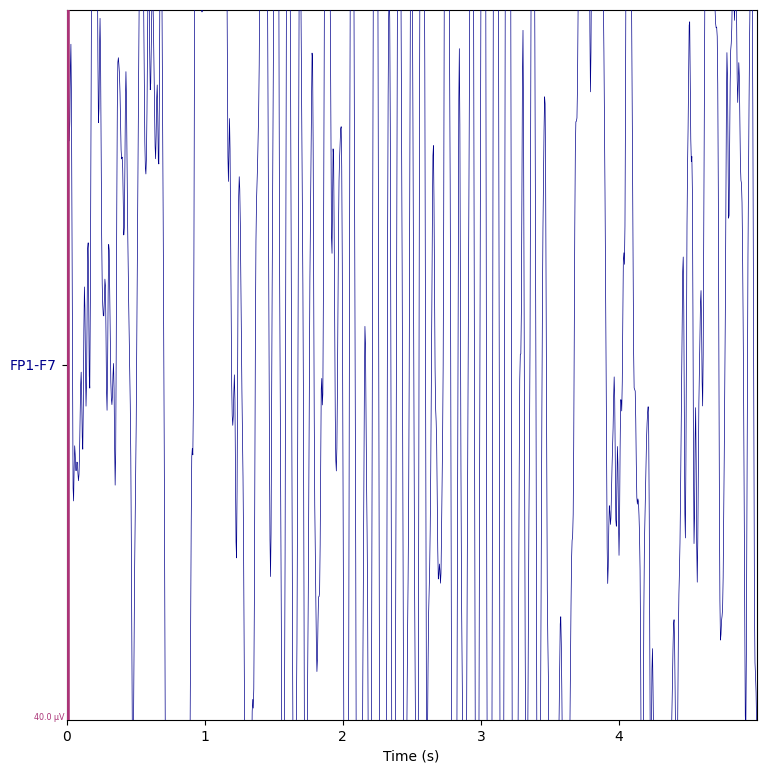

In [10]:
# Ensure plots render directly in the notebook
%matplotlib inline
plt.figure(figsize=(5, 100))
# Plot 10 seconds of the filtered continuous brainwaves for the first 5 electrodes
fig_time = raw.plot(duration=5.0, n_channels=1, color='darkblue',
                    title="Filtered EEG (0.5 - 50 Hz)", show_scrollbars=False,)

# Optional: Save the high-res image to your folder for the video
fig_time.savefig("eeg_time_domain.png", dpi=300)

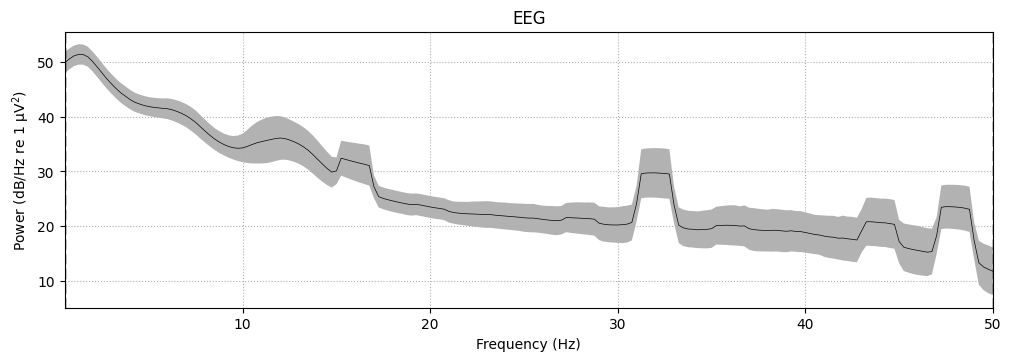

In [11]:
# Compute and plot the Power Spectral Density (PSD) up to 50 Hz
# This shows the actual frequency breakdown of your epochs
psd_fig = epochs.compute_psd(fmin=0.5, fmax=50.0).plot(average=True, spatial_colors=True)

# The resulting graph shows Frequency (Hz) on the X-axis and Power on the Y-axis.
psd_fig.savefig("eeg_frequency_spectrum.png", dpi=300)

In [12]:

#feature engineering
from scipy.signal import welch
import numpy as np

def extract_features_with_spikes(X_raw, sfreq):
    n_windows, n_channels, n_samples = X_raw.shape
# get num epochs x 23 channels x num voltage measurements in each sample
    bands = {
        'Delta': (0.5, 4),
        'Theta': (4, 8),
        'Alpha': (8, 13),
        'Beta': (13, 30),
        'Gamma': (30, 50)
    }

    tabular_data = []

    for i in range(n_windows):
        window_features = []
        #features for current epoch

        for ch in range(n_channels):
            channel_signal = X_raw[i, ch, :]
#for each chanel in each epoch, the voltage in tha epoch -> get the variance of this data
            # 1. Variance (Electrodecremental patterns)
            var_signal = np.var(channel_signal)
            window_features.append(var_signal) # variance of the voltages in this epooch's channel

            # 2-6. Frequency Bands (Rhythmic activity & fast-spiking)
            freqs, psd = welch(channel_signal, fs=sfreq, nperseg=int(sfreq*2))
            #run thru each type of wave ( each band ), get power for that band
            for band_name, (low, high) in bands.items():
                idx_band = np.logical_and(freqs >= low, freqs < high) #detect that band using its freq limits
                band_power = np.sum(psd[idx_band])
                #gets total power in the bad for that band
                window_features.append(band_power)

            # 7. Line Length (Rapid 30-80ms spikes)
            line_length = np.sum(np.abs(np.diff(channel_signal)))
            window_features.append(line_length)
            #abs ensures pos + neg disp dont cancel eo out
            #diff calcs difference between adjacent voltage signals, all this is summed up -> line length

            # 8. Hjorth Mobility (Wave complexity/roughness)
            if var_signal > 0:
                var_derivative = np.var(np.diff(channel_signal))
                hjorth_mobility = np.sqrt(var_derivative / var_signal)
                #hjorth mobilitu v high, var of slope too high in prop var of signal
            else:
                hjorth_mobility = 0.0
            window_features.append(hjorth_mobility)

        tabular_data.append(window_features)
# add all epochs of all channels to tabular_data
    return np.array(tabular_data)

# Execute the extraction
print("Extracting features... this may take a moment.")
X = extract_features_with_spikes(X_raw, sample_rate)
print(f"Feature Matrix X shape: {X.shape}")
print(f"Target Labels y shape: {y.shape}")

Extracting features... this may take a moment.
Feature Matrix X shape: (900, 184)
Target Labels y shape: (900,)


Pre-SMOTE Training Seizures: 8 | Normal: 712
Post-SMOTE Training Seizures: 712 | Normal: 712

Training Random Forest...

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       1.00      1.00      1.00         2

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180

AUC-ROC Score: 1.000


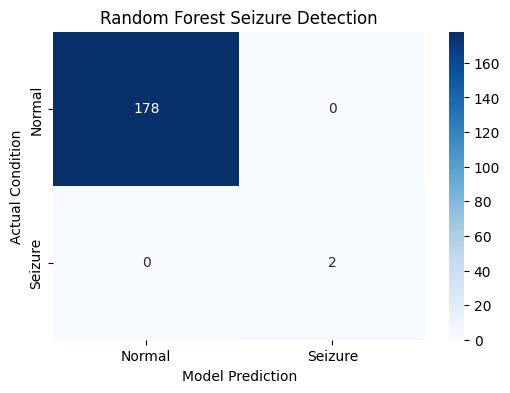

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train/Test Split (80% for training, 20% for testing)
# stratify=y ensures the rare seizure events are distributed evenly across both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Pre-SMOTE Training Seizures: {sum(y_train == 1)} | Normal: {sum(y_train == 0)}")

# 2. Fix the Class Imbalance using SMOTE
# SMOTE generates synthetic "fake but mathematically realistic" seizure epochs to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Post-SMOTE Training Seizures: {sum(y_train_balanced == 1)} | Normal: {sum(y_train_balanced == 0)}")

# 3. Train the Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# 4. Evaluate the Model (Using the untouched test set)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # Get probabilities for AUC-ROC

print("\n--- Classification Report ---")
# Focus on the F1-Score for class 1 (Seizures), not overall accuracy
print(classification_report(y_test, y_pred))

print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.3f}")

# 5. Visualize the Confusion Matrix for your GitHub/Video
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Seizure'],
            yticklabels=['Normal', 'Seizure'])
plt.ylabel('Actual Condition')
plt.xlabel('Model Prediction')
plt.title('Random Forest Seizure Detection')
plt.show()